# Task 2 - Customer Segmentation Analysis

## Objective
Apply K-Means clustering to segment e-commerce customers based on purchasing behaviour using RFM analysis.

## Tech Stack
Python, Pandas, Scikit-learn, Matplotlib, Seaborn, Jupyter Notebook

In [ ]:
pip install scikit-learn

In [1]:
from sklearn.cluster import KMeans

print("KMeans imported successfully")

KMeans imported successfully


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully!
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [9]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5225


In [13]:
print("Negative/Zero Quantity:", (df['Quantity'] <= 0).sum())

Negative/Zero Quantity: 8905


In [14]:
print("Negative/Zero Unit Price:", (df['UnitPrice'] <= 0).sum())

Negative/Zero Unit Price: 40


In [15]:
print("Cancelled Invoices:", df['InvoiceNo'].astype(str).str.startswith('C').sum())

Cancelled Invoices: 8905


In [16]:
df = df.dropna(subset=['CustomerID'])

In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [18]:
df = df[df['Quantity'] > 0]

In [19]:
df = df[df['UnitPrice'] > 0]

In [20]:
df = df.drop_duplicates()

In [21]:
print("Cleaned Dataset Shape:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Cleaned Dataset Shape: (392692, 8)

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [22]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [23]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
average_purchase_value = df['TotalAmount'].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 22.63


In [25]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [26]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [27]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [29]:
print("Average Recency:", round(rfm['Recency'].mean(), 2))
print("Average Purchase Frequency:", round(rfm['Frequency'].mean(), 2))
print("Average Customer Monetary Value:", round(rfm['Monetary'].mean(), 2))

Average Recency: 92.54
Average Purchase Frequency: 4.27
Average Customer Monetary Value: 2048.69


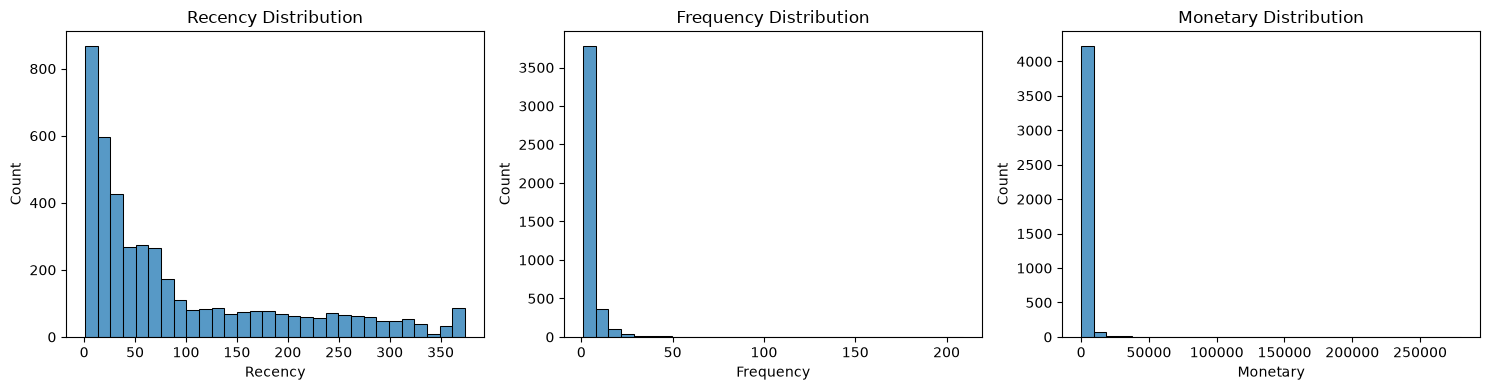

In [30]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [31]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [32]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [33]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

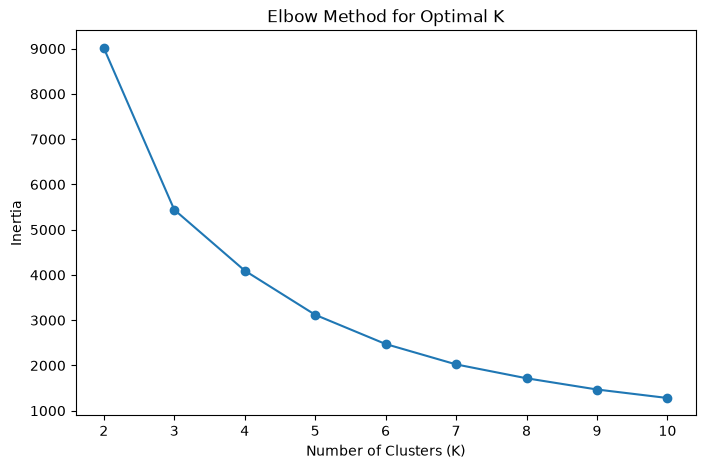

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [35]:
optimal_k = 4

In [36]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [37]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [38]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


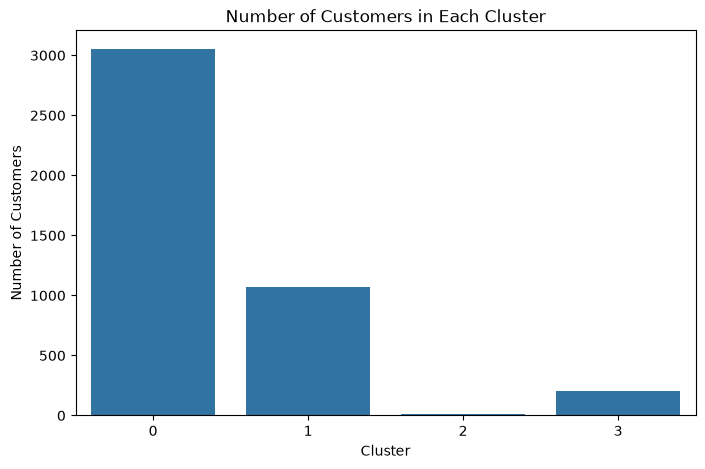

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')

plt.show()

In [40]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [41]:
cluster_names = {
    0: 'At Risk Customers',
    1: 'High Value Customers',
    2: 'Regular Customers',
    3: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,At Risk Customers
12348.0,75,4,1797.24,0,At Risk Customers
12349.0,19,1,1757.55,0,At Risk Customers
12350.0,310,1,334.40,1,High Value Customers


In [42]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
})

segment_summary = segment_summary.rename(
    columns={'Cluster': 'CustomerCount'}
)

segment_summary

,Recency,Frequency,Monetary,CustomerCount
Segment,,,,
At Risk Customers,43.702685,3.682711,1353.625312,3054
High Value Customers,248.075914,1.552015,478.848773,1067
Loyal Customers,15.500000,22.333333,12690.500392,204
Regular Customers,7.384615,82.538462,127187.959231,13


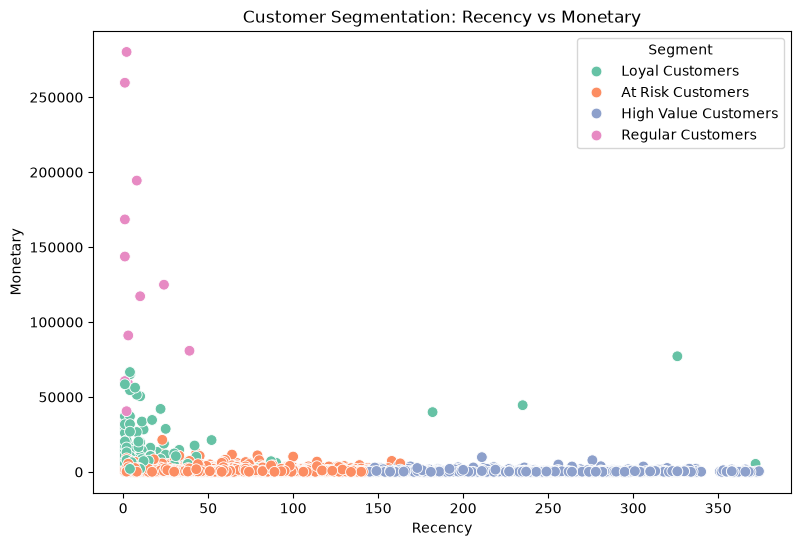

In [43]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='Set2',
    s=60
)

plt.title('Customer Segmentation: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')

plt.show()

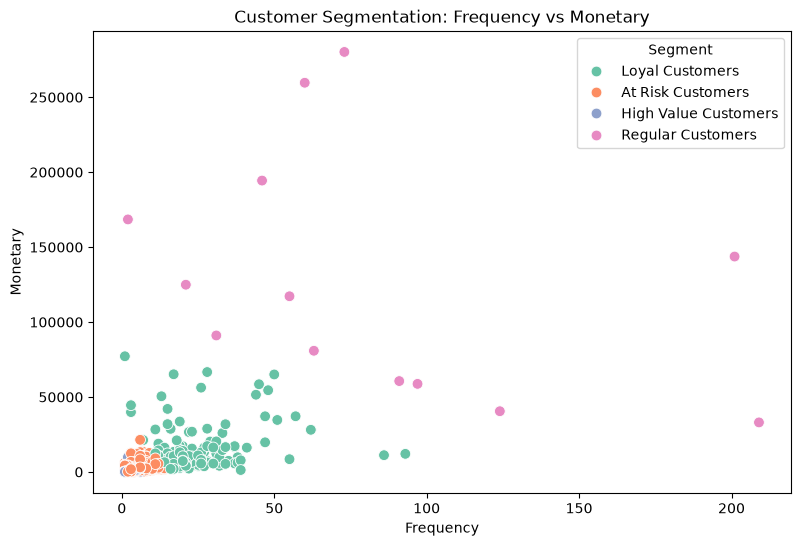

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set2',
    s=60
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

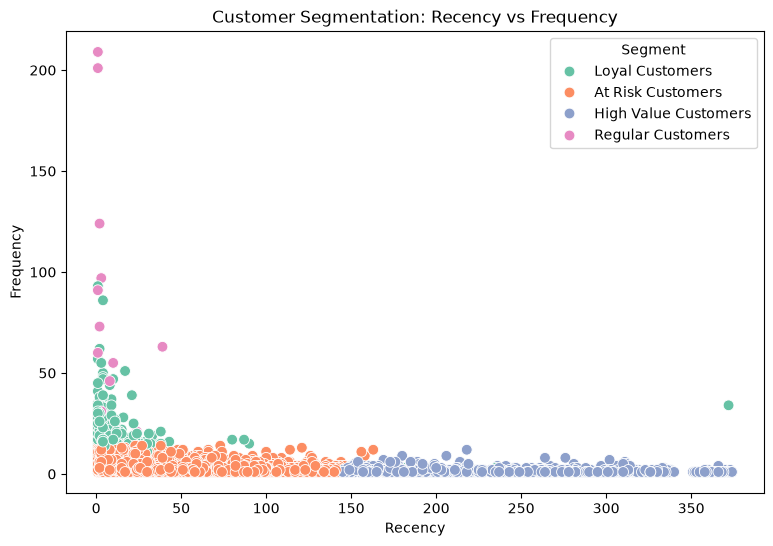

In [45]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    palette='Set2',
    s=60
)

plt.title('Customer Segmentation: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

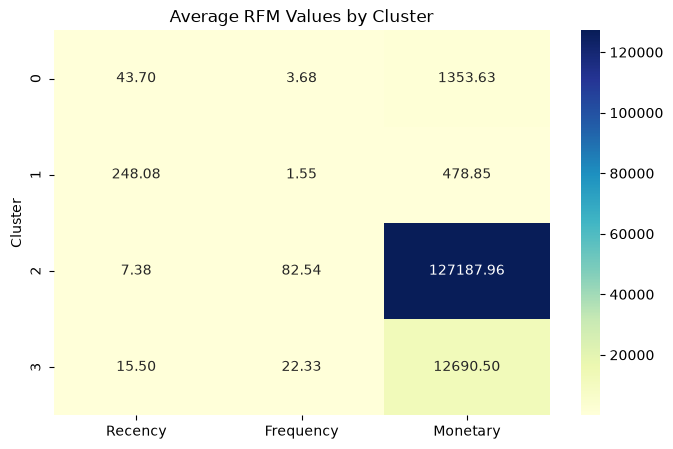

In [46]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average RFM Values by Cluster')

plt.show()

# Key Insights

## Customer Segments

### High Value Customers
These customers have relatively high purchase frequency and monetary value. They can be targeted with loyalty rewards, premium offers, and personalized recommendations.

### Loyal Customers
These customers purchase regularly and show strong engagement. Loyalty programs and repeat-purchase offers can help maintain their relationship.

### Regular Customers
These customers show moderate purchasing activity. Cross-selling, product recommendations, and promotional offers can increase their purchase frequency.

### At Risk Customers
These customers have higher recency values and relatively lower purchasing activity. Win-back campaigns and limited-time discounts can be used to encourage them to return.

## Marketing Recommendations

- High Value Customers → Loyalty rewards and premium offers
- Loyal Customers → Personalized offers and loyalty programs
- Regular Customers → Cross-selling and promotional campaigns
- At Risk Customers → Win-back campaigns and discounts

# Conclusion

This project used RFM analysis and K-Means clustering to segment customers based on their purchasing behaviour.

Recency, Frequency, and Monetary features were calculated for each customer and standardized using StandardScaler. The Elbow Method was used to identify an appropriate number of clusters, followed by K-Means clustering.

The resulting customer segments provide useful insights into customer purchasing behaviour and can support targeted marketing strategies such as loyalty programs, personalized offers, cross-selling, and customer win-back campaigns.